In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.metrics import mean_squared_log_error
from sklearn.model_selection import TimeSeriesSplit
import lightgbm as lgb

pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

# Cargar datos

In [ ]:
DATA_DIR = Path("data")

train = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["date"])
test = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["date"])
stores = pd.read_csv(DATA_DIR / "stores.csv")
oil = pd.read_csv(DATA_DIR / "oil.csv", parse_dates=["date"])
holidays = pd.read_csv(DATA_DIR / "holidays_events.csv", parse_dates=["date"])
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

print(train.shape, test.shape, stores.shape, oil.shape, holidays.shape)
train.head()

(3000888, 6) (28512, 5) (54, 5) (1218, 2) (350, 6)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [4]:
display(train.head())
print(train["sales"].describe())
print(train["date"].min(), train["date"].max())
print(test["date"].min(), test["date"].max())
print(train["store_nbr"].nunique(), train["family"].nunique())
print(train["sales"].isna().sum())

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64
2013-01-01 00:00:00 2017-08-15 00:00:00
2017-08-16 00:00:00 2017-08-31 00:00:00
54 33
0


# EDA

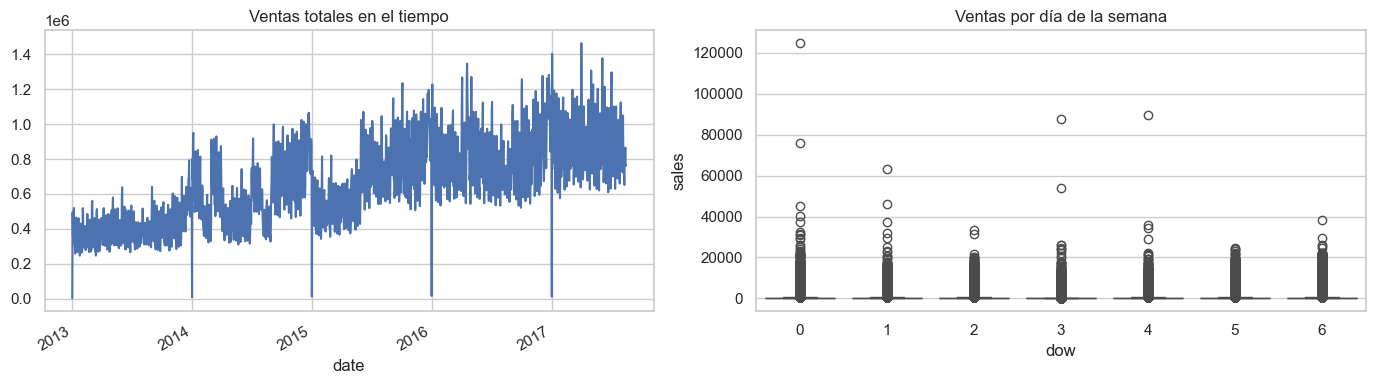

In [5]:
train["dow"] = train["date"].dt.dayofweek
train["month"] = train["date"].dt.month

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

train.groupby("date", as_index=False)["sales"].sum().plot(
    x="date", y="sales", ax=ax[0], legend=False
)
ax[0].set_title("Ventas totales en el tiempo")

sns.boxplot(data=train, x="dow", y="sales", ax=ax[1])
ax[1].set_title("Ventas por día de la semana")

plt.tight_layout()

## Calendario y holidays

In [6]:
full_dates = pd.DataFrame({"date": pd.date_range(train["date"].min(), test["date"].max(), freq="D")})
calendar = full_dates.copy()
calendar["dow"] = calendar["date"].dt.dayofweek
calendar["month"] = calendar["date"].dt.month
calendar["day"] = calendar["date"].dt.day
calendar["weekofyear"] = calendar["date"].dt.isocalendar().week.astype(int)
calendar["year"] = calendar["date"].dt.year
calendar["is_weekend"] = calendar["dow"].isin([5, 6]).astype(int)

holidays = holidays.copy()
holidays["is_holiday"] = 1
holidays["is_transfer"] = (holidays["transferred"] == True).astype(int) if "transferred" in holidays.columns else 0
holidays_feat = holidays[["date", "locale", "locale_name", "type", "is_holiday", "is_transfer"]].copy()

# Features

In [7]:
def build_base(df):
    df = df.copy()
    df["dow"] = df["date"].dt.dayofweek
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)
    df["year"] = df["date"].dt.year
    df["is_weekend"] = df["dow"].isin([5, 6]).astype(int)
    df["is_month_start"] = df["date"].dt.is_month_start.astype(int)
    df["is_month_end"] = df["date"].dt.is_month_end.astype(int)
    return df

def add_lags(df, lags=(1, 7, 14, 28), rolls=(7, 14, 28)):
    df = df.sort_values(["store_nbr", "family", "date"]).copy()
    g = df.groupby(["store_nbr", "family"])["sales"]
    for lag in lags:
        df[f"sales_lag_{lag}"] = g.shift(lag)
    for w in rolls:
        df[f"sales_roll_mean_{w}"] = g.shift(1).rolling(w).mean().reset_index(level=[0, 1], drop=True)
        df[f"sales_roll_std_{w}"] = g.shift(1).rolling(w).std().reset_index(level=[0, 1], drop=True)
    return df

# Preparar training

In [8]:
train2 = train.merge(stores, on="store_nbr", how="left")
train2 = train2.merge(oil.rename(columns={"dcoilwtico": "oil_price"}), on="date", how="left")
train2 = train2.merge(calendar, on="date", how="left")
train2 = train2.merge(holidays_feat[["date", "is_holiday", "is_transfer"]], on="date", how="left")

train2["oil_price"] = train2["oil_price"].ffill().bfill()
train2["is_holiday"] = train2["is_holiday"].fillna(0).astype(int)
train2["is_transfer"] = train2["is_transfer"].fillna(0).astype(int)
train2["onpromotion"] = train2["onpromotion"].astype(int)

train2 = build_base(train2)

def add_lags(df, lags=(1, 7, 14, 28), rolls=(7, 14, 28)):
    df = df.sort_values(["store_nbr", "family", "date"]).copy()

    for lag in lags:
        df[f"sales_lag_{lag}"] = (
            df.groupby(["store_nbr", "family"])["sales"]
            .shift(lag)
        )

    for w in rolls:
        df[f"sales_roll_mean_{w}"] = (
            df.groupby(["store_nbr", "family"])["sales"]
            .transform(lambda s: s.shift(1).rolling(w).mean())
        )
        df[f"sales_roll_std_{w}"] = (
            df.groupby(["store_nbr", "family"])["sales"]
            .transform(lambda s: s.shift(1).rolling(w).std())
        )

    return df

train2 = add_lags(train2)

for c in ["family", "city", "state", "type"]:
    train2[c] = train2[c].astype("category")

train2 = train2.dropna(subset=[
    "sales_lag_1", "sales_lag_7", "sales_lag_14", "sales_lag_28"
])

train2.head()

,id,date,store_nbr,family,sales,onpromotion,dow_x,month_x,city,state,type,cluster,oil_price,dow_y,month_y,day,weekofyear,year,is_weekend,is_holiday,is_transfer,dow,month,is_month_start,is_month_end,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_28,sales_roll_mean_7,sales_roll_std_7,sales_roll_mean_14,sales_roll_std_14,sales_roll_mean_28,sales_roll_std_28
49896,49896,2013-01-29,1,AUTOMOTIVE,2.0,0,1,1,Quito,Pichincha,D,13,97.62,1,1,29,5,2013,0,0,0,1,1,0,0,3.0,1.0,1.0,0.0,2.571429,1.718249,2.142857,1.703261,2.142857,1.458418
51678,51678,2013-01-30,1,AUTOMOTIVE,6.0,0,2,1,Quito,Pichincha,D,13,97.98,2,1,30,5,2013,0,0,0,2,1,0,0,2.0,3.0,1.0,2.0,2.714286,1.603567,2.214286,1.672335,2.214286,1.397276
53460,53460,2013-01-31,1,AUTOMOTIVE,0.0,0,3,1,Quito,Pichincha,D,13,97.65,3,1,31,5,2013,0,0,0,3,1,0,1,6.0,0.0,1.0,3.0,3.142857,2.035401,2.571429,1.910066,2.357143,1.568540
55242,55242,2013-02-01,1,AUTOMOTIVE,3.0,0,4,2,Quito,Pichincha,D,13,97.46,4,2,1,5,2013,0,0,0,4,2,1,0,0.0,5.0,0.0,3.0,3.142857,2.035401,2.500000,1.990361,2.250000,1.624466
57024,57024,2013-02-02,1,AUTOMOTIVE,0.0,0,5,2,Quito,Pichincha,D,13,97.46,5,2,2,5,2013,1,0,0,5,2,0,0,3.0,4.0,5.0,5.0,2.857143,1.864454,2.714286,1.857565,2.250000,1.624466


## Features y target

In [9]:
feature_cols = [
    "store_nbr", "family", "onpromotion", "dow", "month", "day", "weekofyear", "year",
    "is_weekend", "is_month_start", "is_month_end",
    "city", "state", "type", "cluster",
    "oil_price", "is_holiday", "is_transfer",
    "sales_lag_1", "sales_lag_7", "sales_lag_14", "sales_lag_28",
    "sales_roll_mean_7", "sales_roll_mean_14", "sales_roll_mean_28",
    "sales_roll_std_7", "sales_roll_std_14", "sales_roll_std_28"
]

X = train2[feature_cols]
y = np.log1p(train2["sales"])

## Validación temporal

In [10]:
cutoff = train2["date"].max() - pd.Timedelta(days=90)

tr = train2[train2["date"] < cutoff].copy()
va = train2[train2["date"] >= cutoff].copy()

X_tr = tr[feature_cols]
y_tr = np.log1p(tr["sales"])

X_va = va[feature_cols]
y_va = np.log1p(va["sales"])

cat_cols = ["family", "city", "state", "type"]

model = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(
    X_tr, y_tr,
    categorical_feature=cat_cols,
    eval_set=[(X_va, y_va)],
    eval_metric="rmse"
)

pred_va = np.expm1(model.predict(X_va))
pred_va = np.clip(pred_va, 0, None)

rmsle = np.sqrt(mean_squared_log_error(np.expm1(y_va), pred_va))
print("RMSLE validación:", rmsle)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.086570 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3278
[LightGBM] [Info] Number of data points in the train set: 2836944, number of used features: 28
[LightGBM] [Info] Start training from score 2.905532
RMSLE validación: 0.37451084123168155


## Importancia de variables

,feature,importance
1,family,20878
18,sales_lag_1,12983
5,day,12506
11,city,11854
3,dow,11246
15,oil_price,10766
22,sales_roll_mean_7,10679
6,weekofyear,9975
24,sales_roll_mean_28,9138
19,sales_lag_7,8798


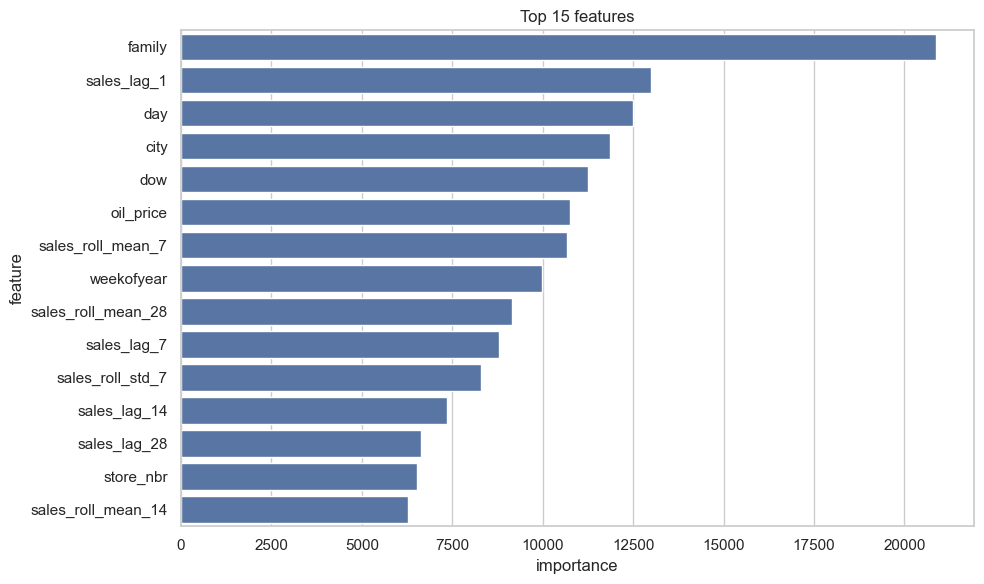

In [11]:
imp = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

display(imp.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=imp.head(15), x="importance", y="feature")
plt.title("Top 15 features")
plt.tight_layout()

# Entrenar modelo final

In [12]:
final_model = lgb.LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.03,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

final_model.fit(train2[feature_cols], np.log1p(train2["sales"]), categorical_feature=cat_cols)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.106811 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3286
[LightGBM] [Info] Number of data points in the train set: 3004452, number of used features: 28
[LightGBM] [Info] Start training from score 2.945444


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,-1
,learning_rate,0.03
,n_estimators,3000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


# Preparar test

In [13]:
test2 = test.merge(stores, on="store_nbr", how="left")
test2 = test2.merge(oil.rename(columns={"dcoilwtico": "oil_price"}), on="date", how="left")
test2 = test2.merge(calendar, on="date", how="left")
test2 = test2.merge(holidays_feat[["date", "is_holiday", "is_transfer"]], on="date", how="left")

test2["oil_price"] = test2["oil_price"].ffill().bfill()
test2["is_holiday"] = test2["is_holiday"].fillna(0).astype(int)
test2["is_transfer"] = test2["is_transfer"].fillna(0).astype(int)
test2["onpromotion"] = test2["onpromotion"].astype(int)

test2 = build_base(test2)
test2.head()

,id,date,store_nbr,family,onpromotion,city,state,type,cluster,oil_price,dow,month,day,weekofyear,year,is_weekend,is_holiday,is_transfer,is_month_start,is_month_end
0,3000888,2017-08-16,1,AUTOMOTIVE,0,Quito,Pichincha,D,13,46.8,2,8,16,33,2017,0,0,0,0,0
1,3000889,2017-08-16,1,BABY CARE,0,Quito,Pichincha,D,13,46.8,2,8,16,33,2017,0,0,0,0,0
2,3000890,2017-08-16,1,BEAUTY,2,Quito,Pichincha,D,13,46.8,2,8,16,33,2017,0,0,0,0,0
3,3000891,2017-08-16,1,BEVERAGES,20,Quito,Pichincha,D,13,46.8,2,8,16,33,2017,0,0,0,0,0
4,3000892,2017-08-16,1,BOOKS,0,Quito,Pichincha,D,13,46.8,2,8,16,33,2017,0,0,0,0,0


## Lags para test

In [14]:
hist = train[["date", "store_nbr", "family", "sales"]].copy()
future = test2[["date", "store_nbr", "family"]].copy()
future["sales"] = np.nan

all_series = pd.concat([hist, future], ignore_index=True)
all_series = all_series.sort_values(["store_nbr", "family", "date"])

# NUEVA FORMA - SIN groupby.apply()
lags = [1, 7, 14, 28]
for lag in lags:
    all_series[f'sales_lag_{lag}'] = (all_series.groupby(['store_nbr', 'family'])['sales']
                                     .transform(lambda x: x.shift(lag)))

windows = [7, 14, 28]
for window in windows:
    all_series[f'sales_roll_mean_{window}'] = (all_series.groupby(['store_nbr', 'family'])['sales']
                                             .transform(lambda x: x.shift(1).rolling(window).mean()))
    all_series[f'sales_roll_std_{window}'] = (all_series.groupby(['store_nbr', 'family'])['sales']
                                            .transform(lambda x: x.shift(1).rolling(window).std()))

print("Columnas después del transform:", all_series.columns.tolist())
# ✅ Verás todas las columnas: date, store_nbr, family, sales, sales_lag_*, etc.

test_feats = test2.merge(
    all_series.drop(columns=["sales"]),
    on=["date", "store_nbr", "family"],
    how="left"
)

for c in ["family", "city", "state", "type"]:
    if c in test_feats.columns:
        test_feats[c] = test_feats[c].astype("category")

for c in feature_cols:
    if c not in test_feats.columns:
        test_feats[c] = np.nan

test_feats[feature_cols].head()

Columnas después del transform: ['date', 'store_nbr', 'family', 'sales', 'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28', 'sales_roll_mean_7', 'sales_roll_std_7', 'sales_roll_mean_14', 'sales_roll_std_14', 'sales_roll_mean_28', 'sales_roll_std_28']


,store_nbr,family,onpromotion,dow,month,day,weekofyear,year,is_weekend,is_month_start,is_month_end,city,state,type,cluster,oil_price,is_holiday,is_transfer,sales_lag_1,sales_lag_7,sales_lag_14,sales_lag_28,sales_roll_mean_7,sales_roll_mean_14,sales_roll_mean_28,sales_roll_std_7,sales_roll_std_14,sales_roll_std_28
0,1,AUTOMOTIVE,0,2,8,16,33,2017,0,0,0,Quito,Pichincha,D,13,46.8,0,0,4.0,7.0,4.0,7.0,4.142857,4.714286,5.035714,3.287784,2.614415,2.847769
1,1,BABY CARE,0,2,8,16,33,2017,0,0,0,Quito,Pichincha,D,13,46.8,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,1,BEAUTY,2,2,8,16,33,2017,0,0,0,Quito,Pichincha,D,13,46.8,0,0,4.0,4.0,2.0,3.0,4.142857,3.928571,3.321429,3.132016,2.525692,2.126614
3,1,BEVERAGES,20,2,8,16,33,2017,0,0,0,Quito,Pichincha,D,13,46.8,0,0,1942.0,2311.0,2645.0,2369.0,1757.000000,1930.357143,2041.178571,633.297981,598.361044,550.522920
4,1,BOOKS,0,2,8,16,33,2017,0,0,0,Quito,Pichincha,D,13,46.8,0,0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.035714,0.000000,0.000000,0.188982


# Predicciones

In [15]:
test_pred = np.expm1(final_model.predict(test_feats[feature_cols]))
test_pred = np.clip(test_pred, 0, None)

submission = sample_submission.copy()
submission["sales"] = test_pred

submission.to_csv("submission.csv", index=False)
submission.head()

,id,sales
0,3000888,4.959977
1,3000889,0.023777
2,3000890,5.357492
3,3000891,2499.315319
4,3000892,0.037621


# Guardar resultados

In [16]:
print("Archivo guardado: submission.csv")
print(submission.shape)

Archivo guardado: submission.csv
(28512, 2)
